In [3]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''
\usepackage{physics} \usepackage{upgreek} \usepackage{mhchem} \usepackage{bm}
'''
import matplotlib.colors as colors
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)
import numpy as np
import scipy, os
import seaborn as sns
import scipy.linalg as LA
import time

os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5")

import tokovi_drugic
import helpers
import tnsmodule

from scipy.optimize import curve_fit

In [6]:
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 500, 1000, 1e-9, 0.5, 0.001, 1.5, 1e-5, 100, 1e-2
parameters1 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 100, 100, 1e-6, 0.5, 0.001, 1.5, 1e-5, 20, 1e-1
parameters2 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

Ny, Nx = 30, 30
s = tnsmodule.TNS(Ny, Nx, mu0 = 2.84, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)
mu = 0.5*(np.min(s.energije[2]) + np.max(s.energije[1]))
s = tnsmodule.TNS(Ny, Nx, mu0=mu, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)

scale = 1.01
omega_max = 0.3
domega = 1e-2
Gamma = 0.01
eps = 1e-5

betas = 300/scale**np.arange(50)
stops = range(len(betas))[1::5]

print(betas[-1])

s.run2(betas, stops, Gamma, omega_max, domega, eps, meja=1e-1, step=100, )#transportE='evaluate',)#) transport='evaluate')

Found ground state with error=7.71722685755094e-11, occupation error=2.220446049250313e-16
Found ground state with error=7.71722685755094e-11, occupation error=2.220446049250313e-16
184.23576388075168
2 300.0 6.383271689003323e-11 1.9999999999999956 0.1476647805405634
1 297.029702970297 5.279843229288872e-11 1.9999999999999998 0.14766478052446064
2 294.08881482207624 6.382661066339779e-11 1.9999999999999913 0.14766478054055418
2 291.1770443782933 5.2798654337493645e-11 1.999999999999997 0.14766478052444773
2 288.29410334484487 4.367395334270441e-11 1.999999999999999 0.14766478051112217
2 285.4397062820246 3.612732335511737e-11 2.0 0.1476647805000941
1 282.61357057626196 2.988354008692795e-11 1.9999999999999993 0.14766478049096735
2 279.8154164121406 3.610756138527904e-11 1.999999999999999 0.14766478050006354
2 277.0449667446936 2.9851565663818747e-11 1.9999999999999987 0.1476647804909245
2 274.3019472719739 2.4697355271996457e-11 1.9999999999999987 0.14766478048335413
2 271.58608640789

In [12]:
U = 2.5 # eV
V = 0.785 # eV
a = 3.51 # A
b = 15.79 # A
b2 = 1.927 # A
omegas = np.linspace(-0.5,0.5,100)
j2_MF = tokovi_drugic.j_MF(s.kymesh, s.kxmesh, s.rho, V, a, b, b2, )
Gamma=0.05
phi = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, s.mu, omegas, Gamma=Gamma, simplify=None)
transportna_K, transportna_I = tokovi_drugic.transportna_phiE(s.kymesh, s.vecs, s.energije, s.j_matrix, s.j1_matrix, j2_MF, s.mu, omegas, Gamma=Gamma)

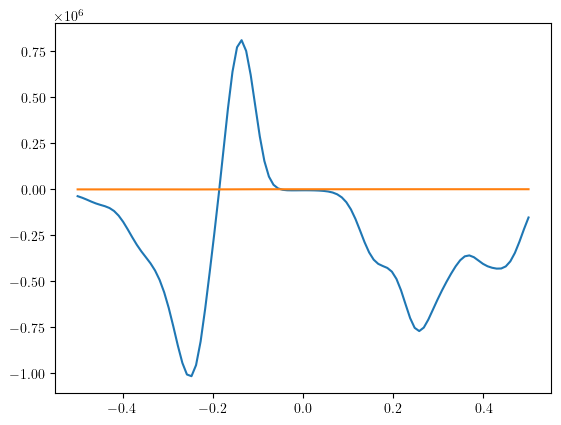

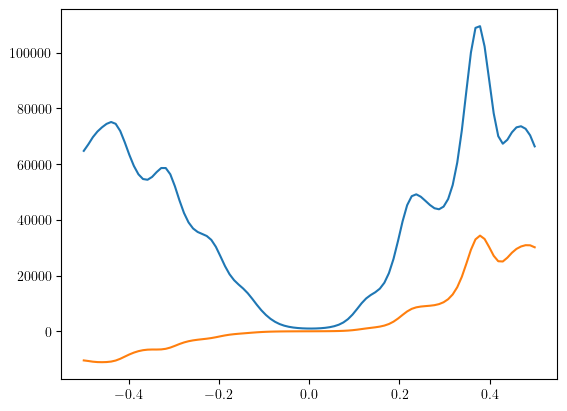

In [39]:
plt.plot(omegas, transportna_I[1].real * transportna_K[1].real)
plt.plot(omegas, omegas * phi[0][1].real)
plt.show()

plt.plot(omegas, -transportna_I[0].real - transportna_K[0].real)
plt.plot(omegas, omegas * phi[0][0].real)
plt.show()

In [340]:
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 500, 1000, 1e-9, 0.5, 0.001, 1.5, 1e-5, 100, 1e-2
parameters1 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 100, 100, 1e-6, 0.5, 0.001, 1.5, 1e-5, 20, 1e-1
parameters2 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

Ny, Nx = 100, 100
s2 = tnsmodule.TNS(Ny, Nx, mu0 = 2.84, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)
mu = 0.5*(np.min(s2.energije[2]) + np.max(s2.energije[1]))
s2 = tnsmodule.TNS(Ny, Nx, mu0=mu, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)


gap = np.min(s2.energije[2]) - np.max(s2.energije[1])
print(f'gap={gap}')

scale = 1.01
omega_max = 0.3
domega = 1e-2
Gamma = 0.01
eps = 1e-5

betas = 400/scale**np.arange(30)
stops = range(len(betas))[1::5]

print(betas[-1])

s2.run2(betas, stops, Gamma, omega_max, domega, eps, meja=1e-3, step=100, transportB='evaluate',)#) transport='evaluate')

Found ground state with error=7.7195694281329e-11, occupation error=1.3322676295501878e-15
Found ground state with error=7.7195694281329e-11, occupation error=1.3322676295501878e-15
gap=0.17629887979859005
299.73685878599815


C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:105: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, 0, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:113: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, Ny//2, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:122: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, m, 0], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:146: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, m, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:147: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, -m, -n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:161: RuntimeWarning: overflow encountered in exp
  

2 400.0 2.0793203751099463e-08 1.9999999978109468 0.14766544195434725
1 396.03960396039605 4.128100083988793e-10 1.9999999989638984 0.14766544184839459


C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\tokovi_drugic.py:182: RuntimeWarning: overflow encountered in scalar power
  def fd_1(omega, T): return -1/(4*T)/np.cosh(omega/(2*T))**2


2 392.1184197627684 2.8090335535328942e-08 1.9999999969808244 0.14766544161133244
2 388.2360591710577 1.59070481231538e-08 1.999999998570518 0.1476654417123226
2 384.39213779312655 7.320159811641247e-09 1.9999999993169784 0.14766544185881628
2 380.58627504269947 3.3122923557306157e-09 1.9999999996706932 0.14766544199914594
1 376.8180941016826 1.6630641308523764e-10 1.9999999998398013 0.1476654422046411
2 373.0872218828541 2.174079217441285e-09 1.9999999995349123 0.1476654419430145
2 369.39328899292485 2.125158609722729e-09 1.9999999997737727 0.1476654420716969
2 365.73592969596524 9.773962546419953e-10 1.9999999998889844 0.1476654421852271
2 362.1147818771933 4.3573360836686175e-10 1.999999999945047 0.1476654422822048
1 358.5294870071221 2.2961965662204875e-10 1.999999999972572 0.14766544236394247
2 354.97969010606147 2.338659266243326e-10 1.9999999999195306 0.14766544227165096
2 351.46503970897174 2.8830845494211013e-10 1.9999999999598528 0.1476654423541095
2 347.98518783066504 2.0140

In [430]:
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 500, 1000, 1e-8, 0.5, 0.001, 1.5, 1e-5, 100, 1e-2
parameters1 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1 = 0.001, 100, 100, 1e-5, 0.5, 0.001, 1.5, 1e-5, 20, 1e-1
parameters2 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials, faktor1]

Ny, Nx = 100, 100
#s4 = tnsmodule.TNS(Ny, Nx, mu0 = 2.84, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)
mu = 0.5*(np.min(s4.energije[2]) + np.max(s4.energije[1]))
#s4 = tnsmodule.TNS(Ny, Nx, mu0=mu, parameters1=parameters1, parameters2=parameters2, eps_gs=1e-10)

scale = 1.05
omega_max = 0.3
domega = 1e-2
Gamma = 0.05
eps = 1e-5

betas = np.hstack([380/scale**np.arange(71), 380/scale**71/1.01**np.arange(20)])
stops = range(len(betas))[71::3]

print(betas[-1])

s4.run2(betas, stops, Gamma, omega_max, domega, eps, meja=1e-3, step=200, transport='evaluate')

9.84548830825392


C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:105: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, 0, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:113: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, Ny//2, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:122: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, m, 0], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:146: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, m, n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:147: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, -m, -n], 1/(1 + np.exp((en - mu)/T)))
C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\helpers.py:161: RuntimeWarning: overflow encountered in exp
  

2 380.0 8.021022783633036e-06 1.999999999999995 0.1476504619398469
2 361.90476190476187 8.489521380217191e-06 1.999999999999992 0.1476530499890477
2 344.6712018140589 7.02307349653708e-06 1.9999999999999833 0.14765519096036517
2 328.2582874419609 5.809889840557858e-06 1.999999999999976 0.14765696207691323
2 312.6269404209151 4.806246462485397e-06 1.9999999999999678 0.14765842722559064
2 297.73994325801436 3.975960899182951e-06 1.9999999999999543 0.14765963925960535
2 283.5618507219184 3.289095362180028e-06 1.9999999999999558 0.14766064190350192
2 270.0589054494461 2.7208802210187955e-06 1.9999999999999611 0.14766147132941249
2 257.19895757090103 2.2508224984951752e-06 1.9999999999999576 0.1476621574612014
2 244.95138816276292 1.8619680383080706e-06 1.9999999999999325 0.14766272505334835
2 233.28703634548847 1.5402910304995743e-06 1.9999999999998288 0.14766319458322769
2 222.17812985284618 1.2741892655432352e-06 1.9999999999995621 0.1476635829885199
2 211.5982189074725 1.054067321315521

In [429]:
scale = 1.05
omega_max = 0.3
domega = 1e-2
Gamma = 0.05
eps = 1e-5

betas = np.hstack([380/scale**np.arange(71), 380/scale**71/1.01**np.arange(20)])
stops = range(len(betas))[71::3]

print(betas[-1])

list(stops)

9.84548830825392


[71, 74, 77, 80, 83, 86, 89]

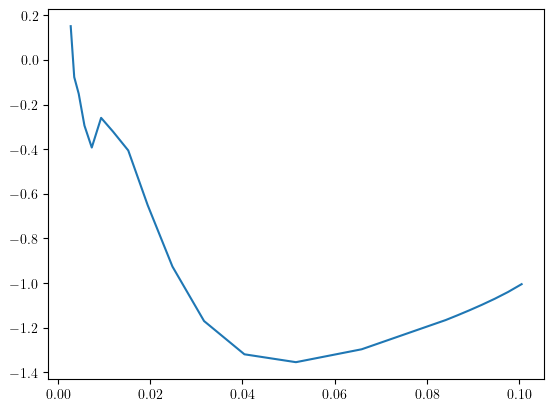

In [434]:
plt.plot(s4.Ts, -np.array(s4.L12_xx)/np.array(s4.L11_xx) / np.array(s4.Ts))

In [435]:
np.save('mus4.npy', s4.mus)
np.save('phis4.npy', s4.phis)
np.save('Ts4.npy', s4.Ts)
np.save('L11_xx4.npy', s4.L11_xx)
np.save('L12_xx4.npy', s4.L12_xx)
np.save('L11_yy4.npy', s4.L11_yy)
np.save('L12_yy4.npy', s4.L12_yy)

In [397]:
np.load('L11_xx3.npy')

array([5.68075885e+02, 4.52060199e+02, 3.77967921e+02, 3.30983175e+02,
       3.03070203e+02, 2.90460689e+02, 2.91378444e+02, 2.93477026e+02,
       2.94044676e+02, 2.94605482e+02, 2.95233731e+02, 2.95935346e+02,
       2.96716696e+02, 2.97588722e+02, 2.98565341e+02, 2.99664431e+02,
       3.00908980e+02, 3.02330081e+02, 3.03971083e+02, 3.05894148e+02,
       3.08190163e+02, 3.10993597e+02, 3.14504178e+02, 3.19017812e+02,
       3.24969615e+02, 3.32992378e+02, 3.43994079e+02, 3.59258149e+02,
       3.80570227e+02, 4.10374637e+02, 4.51963271e+02, 5.09698630e+02,
       5.89271831e+02, 6.97994780e+02, 8.45125092e+02, 1.04222118e+03,
       1.30352417e+03, 1.64636029e+03, 2.09156761e+03, 2.66393556e+03,
       3.39266369e+03, 4.31182565e+03, 5.46087935e+03, 6.88517385e+03,
       8.63649207e+03, 1.07737214e+04, 1.33633198e+04, 1.64805902e+04,
       2.02096498e+04, 2.46604362e+04, 2.98977014e+04, 3.60929658e+04,
       4.32926505e+04, 5.17871503e+04, 6.15865581e+04, 7.30320457e+04,
      

In [341]:
np.save('mus.npy', s.mus)
np.save('phis.npy', s.phis)
np.save('Ts.npy', s.Ts)
np.save('L11_xx_boltz.npy', s.L11_xx_boltz)
np.save('L12_xx_boltz.npy', s.L12_xx_boltz)
np.save('L11_yy_boltz.npy', s.L11_yy_boltz)
np.save('L12_yy_boltz.npy', s.L12_yy_boltz)

np.save('mus2.npy', s2.mus)
np.save('phis2.npy', s2.phis)
np.save('Ts2.npy', s2.Ts)
np.save('L11_xx_boltz2.npy', s2.L11_xx_boltz)
np.save('L12_xx_boltz2.npy', s2.L12_xx_boltz)
np.save('L11_yy_boltz2.npy', s2.L11_yy_boltz)
np.save('L12_yy_boltz2.npy', s2.L12_yy_boltz)

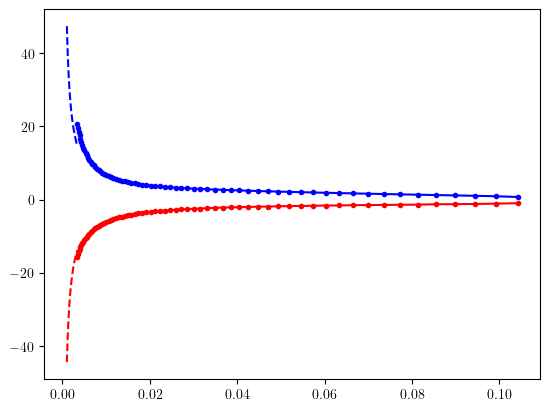

In [339]:
col1 = 'red'
col2 = 'blue'

plt.plot(s.Ts, -np.array(s.L12_yy_boltz)/np.array(s.L11_yy_boltz) / np.array(s.Ts), '.-', color=col2)
plt.plot(s.Ts, -np.array(s.L12_xx_boltz)/np.array(s.L11_xx_boltz) / np.array(s.Ts), '.-', color=col1)



gap = np.min(s2.energije[2]) - np.max(s2.energije[1])
m_x = 1.41 / 0.48
m_y = 1.65 / 5.3 
z = 2

m = np.sqrt(1.41*1.65/0.48*5.3)

ts = np.linspace(0.001,s.Ts[0],1000)

plt.plot(ts, (1-m_x)/(1+m_x) * (gap/2/ts + 2) + 1/2*ts*np.log(m) + 1/2*ts*np.log(z), '--', color='red')
#plt.plot(ts, (1-m_x/z)/(1+m_x/z) * (gap/2/ts + 2) + 1/2*np.log(m_x) + 1/2*np.log(z), color=col1, ls='dotted')
plt.plot(ts, (1-m_y)/(1+m_y) * (gap/2/ts + 2) + 1/2*ts*np.log(m) + 1/2*ts*np.log(z), color=col2, ls='dashed')
#plt.plot(ts, (1-m_y/z)/(1+m_y/z) * (gap/2/ts + 2) + 1/2*np.log(m_y) + 1/2*np.log(z), color=col2, ls='dotted')

250.0

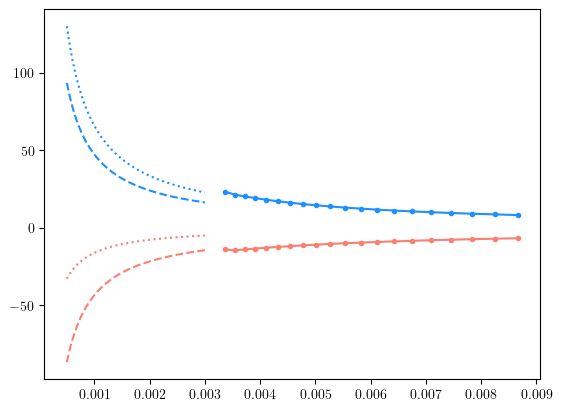

In [26]:
col1 = 'salmon'
col2 = 'dodgerblue'

#plt.plot(s.Ts, -np.array(s.L12_xx)/np.array(s.L11_xx)/s.Ts, '.-',color='maroon')
#plt.plot(s.Ts, -np.array(s.L12_yy)/np.array(s.L11_yy)/s.Ts, '.-', color='navy')
plt.plot(s.Ts, -np.array(s.L12_xx_boltz)/np.array(s.L11_xx_boltz)/s.Ts, '.-', color=col1)
plt.plot(s.Ts, -np.array(s.L12_yy_boltz)/np.array(s.L11_yy_boltz)/s.Ts, '.-', color=col2)

gap = np.min(s.energije[2]) - np.max(s.energije[1])
m_x = 1.41 / 0.48
m_y = 1.65 / 5.3
z = 2

ts = np.linspace(0.0005,0.003,1000)



plt.plot(ts, (1-m_x)/(1+m_x) * (gap/2/ts + 2) + 1/2*np.log(m_x) + 1/2*np.log(z), color=col1, ls='dashed')
plt.plot(ts, (1-m_x/z)/(1+m_x/z) * (gap/2/ts + 2) + 1/2*np.log(m_x) + 1/2*np.log(z), color=col1, ls='dotted')
plt.plot(ts, (1-m_y)/(1+m_y) * (gap/2/ts + 2) + 1/2*np.log(m_y) + 1/2*np.log(z), color=col2, ls='dashed')
plt.plot(ts, (1-m_y/z)/(1+m_y/z) * (gap/2/ts + 2) + 1/2*np.log(m_y) + 1/2*np.log(z), color=col2, ls='dotted')

1/0.004

In [5]:
omegas = np.linspace(-0.5,0.5,100)

phiB, jnewB = tokovi_drugic.transportna_phi_Boltzmann(s.kymesh, s.kxmesh, s.energije, mu, omegas, faktor=0.3)
phi, jnew = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.01)
#phi1, jnew1 = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.005)
#phi2, jnew2 = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.003)

phi_s, jnew = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.01, simplify='yes')
#phi1_s, jnew1 = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.005, simplify='yes')
#phi2_s, jnew2 = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, mu, omegas, Gamma=0.003, simplify='yes')


In [117]:
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials = 0.001, 100, 1000, 1e-8, 0.5, 0.001, 1.5, 1e-3, 30
parameters1 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials]

dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials = 0.001, 10, 10, 1e-5, 0.5, 0.001, 1.5, 1e-3, 30
parameters2 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials]

Ny, Nx =150, 150
mu = 2.84
eps0 = 0.1
#s = tnsmodule.TNS(Ny, Nx, parameters1=parameters1, parameters2=parameters2)
mu = 0.5*(np.min(s.energije[2]) + np.max(s.energije[1]))
s = tnsmodule.TNS(Ny, Nx, mu0=mu, parameters1=parameters1, parameters2=parameters2)



Found ground state with error=7.720513117703831e-11, occupation error=1.3322676295501878e-15


In [174]:
transB, _, _ = tokovi_drugic.transportna_phi_Boltzmann(s.kymesh, s.kxmesh, s.energije, s.mu, omega_max=0.5, domega=0.01, faktor=0.2)

omega_max = 0.5
domega = 0.01
omegas = np.arange(-omega_max, omega_max, domega)
#trans, _ = tokovi_drugic.transportna_phi(s.kymesh, s.vecs, s.energije, s.j_matrix, s.mu, omegas, Gamma=0.01)

In [178]:
betas = np.linspace(5,150,50)
Ts = 1/betas

S_x, S_xB, S_y, S_yB = [], [], [], []

for T in Ts:
    
    l12_x = np.sum(-tokovi_drugic.fd_1(omegas, T) * omegas * trans[0])
    l11_x = np.sum(-tokovi_drugic.fd_1(omegas, T) * trans[0])

    l12_y = np.sum(-tokovi_drugic.fd_1(omegas, T) * omegas * trans[1])
    l11_y = np.sum(-tokovi_drugic.fd_1(omegas, T) * trans[1])

    l12_xB = np.sum(-tokovi_drugic.fd_1(omegas, T) * omegas * transB[0])
    l11_xB = np.sum(-tokovi_drugic.fd_1(omegas, T) * transB[0])

    l12_yB = np.sum(-tokovi_drugic.fd_1(omegas, T) * omegas * transB[1])
    l11_yB = np.sum(-tokovi_drugic.fd_1(omegas, T) * transB[1])

    S_x.append(-l12_x/l11_x / T)
    S_y.append(-l12_y/l11_y / T)
    S_xB.append(-l12_xB/l11_xB / T)
    S_yB.append(-l12_yB/l11_yB / T)

In [9]:
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials = 0.001, 100, 2000, 1e-9, 0.5, 0.001, 1.5, 1e-3, 30
parameters1 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials]

dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials = 0.001, 10, 10, 1e-6, 0.5, 0.001, 1.5, 1e-3, 30
parameters2 = [dmu, maxiter, maxiter_last, eps_last, mix, mix2, mix3, n_pass, max_trials]

#Ny, Nx = 80, 80
mu = 2.84
eps0 = 0.1
# = tnsmodule.TNS(Ny, Nx, parameters1=parameters1, parameters2=parameters2)

beta0 = 200
scale = 1.05
betas = np.linspace(100,200,1)[::-1]
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas

domega = 1e-3
'''Gamma = 0.01
for i, T in enumerate(Ts):
    print(1/T)
    print('-------------')
    s.reset(mu)
    set_betas = beta0/scale**np.arange(ends[i])
    set_Ts = 1/set_betas
    s.run(set_Ts, Gamma, domega,)# transportB='evaluate', transport='evaluate', eps=1e-2)
    if len(s.phis) > 1: print(s.phis[-1])'''

"Gamma = 0.01\nfor i, T in enumerate(Ts):\n    print(1/T)\n    print('-------------')\n    s.reset(mu)\n    set_betas = beta0/scale**np.arange(ends[i])\n    set_Ts = 1/set_betas\n    s.run(set_Ts, Gamma, domega,)# transportB='evaluate', transport='evaluate', eps=1e-2)\n    if len(s.phis) > 1: print(s.phis[-1])"

Found ground state with error=8.200762291465935e-11, occupation error=4.440892098500626e-16
[1.82550936e-10 7.60148619e-11]
[-1.70504654e-11 -7.33258547e-12]


C:\Users\anast\OneDrive\Namizje\1m\poletje\ta2nise5\tokovi_drugic.py:182: RuntimeWarning: overflow encountered in scalar power
  def fd_1(omega, T): return -1/(4*T)/np.cosh(omega/(2*T))**2


Found ground state with error=7.555389647251332e-11, occupation error=4.440892098500626e-16
[2.10738195e-10 9.64706935e-11]
[-1.89195877e-11 -9.53229432e-12]
Found ground state with error=7.60088658680047e-11, occupation error=8.881784197001252e-16
[5.90277369e-10 2.15692787e-10]
[ 2.08866469e-11 -2.04507698e-11]
Found ground state with error=7.602385387883714e-11, occupation error=6.661338147750939e-16
[2.55090963e-09 3.48161134e-10]
[ 1.69105386e-10 -2.91854257e-11]
Found ground state with error=7.602674045870117e-11, occupation error=2.220446049250313e-15
[5.63765725e-09 5.55527052e-10]
[ 4.26835446e-10 -3.77651780e-11]
Found ground state with error=7.602729557021348e-11, occupation error=0.0
[9.1034596e-09 8.3067493e-10]
[ 7.00007387e-10 -4.50022023e-11]
Found ground state with error=7.602596330258393e-11, occupation error=1.7763568394002505e-15
[1.25517634e-08 1.17011437e-09]
[ 9.65844972e-10 -5.15237224e-11]
Found ground state with error=7.602751761481841e-11, occupation error=1.

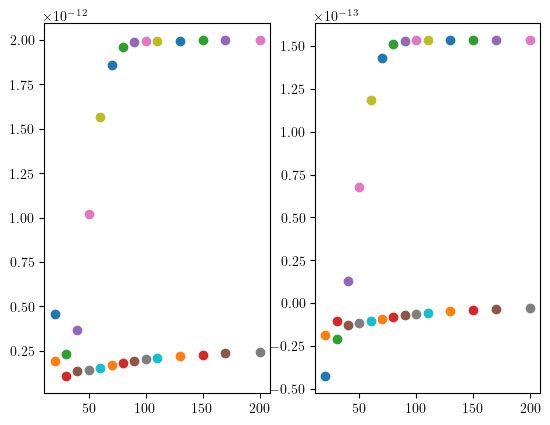

In [10]:
Ns = [20,30,40,50,60,70,80,90,100,110,130,150,170,200]

omegas = np.arange(-0.5,0.5,0.001)
Gamma = 0.01
fig, ax = plt.subplots(ncols=2)

l11_x = []
l11_y = []
l12_x = []
l12_y = []

for i, N in enumerate(Ns):
    Ny, Nx = N, N
    s = tnsmodule.TNS(Ny, Nx, parameters1=parameters1, parameters2=parameters2, eps0=1e-8)

    kx = s.kxmesh[0]
    ky = s.kymesh[:,0]

    _, _, l11, l12 = tokovi_drugic.L_Boltzmann(s.kymesh, s.kxmesh, s.energije, s.mu, 1/300)
    ax[0].scatter(N, l11[0] /s.Nk)#/ l11[0] ) 
    ax[0].scatter(N, l11[1] /s.Nk)#/ l11[1] ) 

    ax[1].scatter(N, l12[0] /s.Nk)#/ l11[0] ) 
    ax[1].scatter(N, l12[1] /s.Nk)#/ l11[1] ) 

    l11_x.append(l11[0])
    l11_y.append(l11[1])
    l12_x.append(l12[0])
    l12_y.append(l12[1])
    print(l11)
    print(l12)

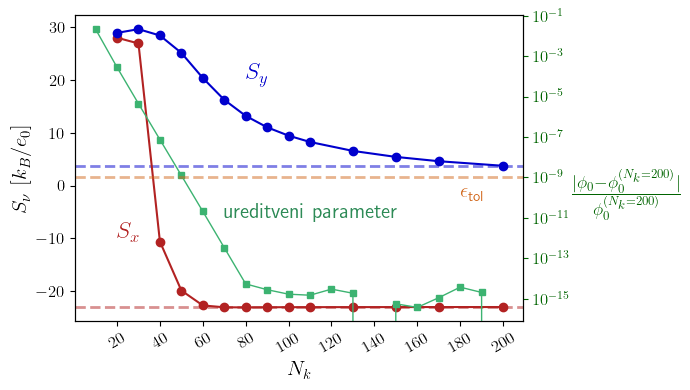

In [60]:
fig, ax = plt.subplots(figsize=(7,4))
plt.plot(Ns, -np.array(l12_x)/np.array(l11_x)/(1/300), 'o-',  color='firebrick', label=r'$\nu=x$')
plt.plot(Ns, -np.array(l12_y)/np.array(l11_y)/(1/300), 'o-',  color='mediumblue', label=r'$\nu=y$')
         
plt.axhline(-np.array(l12_x)[-1]/np.array(l11_x)[-1]/(1/300), color='firebrick', zorder=-100, alpha=0.5, lw=2, ls='dashed')
plt.axhline(-np.array(l12_y)[-1]/np.array(l11_y)[-1]/(1/300), color='mediumblue', zorder=-100, alpha=0.5, lw=2, ls='dashed')

ax.text(20,-10,'$S_x$', color='firebrick', fontsize=17)
ax.text(80,20,'$S_y$', color='mediumblue', fontsize=17)

ax.set_xticks([20,40,60,80,100,120,140,160,180,200])
ax.set_xticklabels([rf'${u}$' for u in [20,40,60,80,100,120,140,160,180,200]], fontsize=12, rotation=30)
ax.set_xlabel(r'$N_k$', fontsize=15)
ax.set_yticks([-20,-10,0,10,20,30])
ax.set_yticklabels([rf'${u}$' for u in [-20,-10,0,10,20,30]], fontsize=12)
ax.set_ylabel(r'$S_\nu\,\,[k_B/e_0]$', fontsize=15)


os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\1m\\poletje\\ta2nise5\\parameters")
data = np.load('konvergenca-phi0.npy')

ax2 = ax.twinx()
ax2.plot(data[0], np.abs(data[1] - data[1][-1])/data[1][-1], 's-',  lw=1, ms=5, zorder=-10000, color='mediumseagreen')
ax2.set_yscale('log')
ax2.set_yticks([1e-15,1e-13,1e-11,1e-9,1e-7,1e-5,1e-3, 1e-1])
ax2.set_yticklabels([r'$10^{-15}$', r'$10^{-13}$', r'$10^{-11}$', r'$10^{-9}$', r'$10^{-7}$', r'$10^{-5}$', r'$10^{-3}$', r'$10^{-1}$'], fontsize=12)
ax2.text(70,1e-11,r'ureditveni parameter', color='seagreen', fontsize=15)
ax2.tick_params(axis='y', colors='darkgreen')
ax2.yaxis.label.set_color('darkgreen')
#ax2.axhline(1e-9*0.9995, color='black', ls='dashed', zorder=-100, lw=1)
ax2.axhline(1e-9, color='chocolate', ls='dashed', zorder=-100, lw=2, alpha=.5)

#ax2.text(179.5, 1e-10*0.93, r'$\varepsilon_{\text{tol}}$', color='black', fontsize=15)
ax2.text(180, 1e-10, r'$\epsilon_{\text{tol}}$', color='chocolate', fontsize=15)

ax2.set_ylabel(r'$\frac{|\phi_0 - \phi_0^{(N_k=200)}|}{\phi_0^{(N_k=200)}}$', fontsize=18, rotation=0, labelpad=40)
''' konvergenca seebeckovega koef z N'''
plt.tight_layout()
os.chdir("C:\\Users\\anast\\OneDrive\\Namizje\\2m\\magistrska\\slike")
plt.savefig('konvergenca.pdf')